# Кластеризация покупателей методом K-Means

## Что такое кластеризация?

Кластеризация — это метод **обучения без учителя** (unsupervised learning).  
У нас нет правильных ответов — алгоритм сам находит группы (кластеры) похожих объектов.

**Применение в бизнесе:** разбить покупателей на сегменты, чтобы делать персонализированные предложения.

---

## Наш датасет: Online Retail II

Транзакции онлайн-магазина из Великобритании за 2009–2011 годы.

| Колонка | Описание |
|---|---|
| Invoice | Номер заказа |
| StockCode | Код товара |
| Description | Название товара |
| Quantity | Количество |
| InvoiceDate | Дата и время |
| Price | Цена за единицу |
| Customer ID | ID покупателя |
| Country | Страна |

## Стратегия: RFM-анализ

Вместо того чтобы кластеризовать сырые транзакции, мы создадим **3 признака на каждого покупателя**:

- **R (Recency)** — как давно он последний раз покупал (в днях)
- **F (Frequency)** — сколько раз он совершал покупки
- **M (Monetary)** — сколько денег он потратил всего

Это превратит миллионы строк транзакций → одну строку на покупателя.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Библиотеки загружены!')

Библиотеки загружены!


## Шаг 1: Загрузка и изучение данных (EDA)

Первое, что делают с любым датасетом — смотрят на него. Сколько строк? Есть ли пропуски? Какие типы данных?

In [2]:
df = pd.read_csv('../data/online_retail_II.csv', parse_dates=['InvoiceDate'])

print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} колонок')
print()
df.head()

Размер датасета: 525,461 строк, 8 колонок



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [3]:
print('Типы данных и пропуски:')
print(df.info())
print()
print('Количество пропусков:')
print(df.isnull().sum())

Типы данных и пропуски:
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  str           
 1   StockCode    525461 non-null  str           
 2   Description  522533 non-null  str           
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 32.1 MB
None

Количество пропусков:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [4]:
print('Базовая статистика числовых колонок:')
df[['Quantity', 'Price']].describe()

Базовая статистика числовых колонок:


,Quantity,Price
count,525461.00,525461.00
mean,10.34,4.69
std,107.42,146.13
min,-9600.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.21
max,19152.00,25111.09


## Шаг 2: Очистка данных

Реальные данные всегда «грязные». Нужно убрать:
- строки без `Customer ID` (мы не знаем, кто покупал)
- отмены заказов (Invoice начинается с 'C')
- строки с отрицательным количеством или ценой

In [5]:
print(f'До очистки: {len(df):,} строк')

# Убираем строки без покупателя
df = df.dropna(subset=['Customer ID'])
print(f'После удаления пропусков Customer ID: {len(df):,} строк')

# Убираем отменённые заказы (код начинается с 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f'После удаления отмен: {len(df):,} строк')

# Убираем некорректные значения
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f'После удаления Quantity/Price <= 0: {len(df):,} строк')

# Добавляем колонку выручки по строке
df['Revenue'] = df['Quantity'] * df['Price']

print(f'\nОсталось {len(df)/525462*100:.1f}% от исходных данных')

До очистки: 525,461 строк
После удаления пропусков Customer ID: 417,534 строк


После удаления отмен: 407,695 строк
После удаления Quantity/Price <= 0: 407,664 строк

Осталось 77.6% от исходных данных


## Шаг 3: Вычисление RFM-метрик

Агрегируем транзакции → один покупатель = одна строка с тремя числами.

**Recency** считается относительно «сегодняшней» даты — возьмём дату на 1 день позже последней транзакции в датасете.

In [6]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Дата отсчёта: {reference_date.date()}')

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),   # уникальных заказов
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\nПокупателей всего: {len(rfm):,}')
rfm.head(10)

Дата отсчёта: 2010-12-10



Покупателей всего: 4,312


,Customer ID,Recency,Frequency,Monetary
0,12346.00,165,11,372.86
1,12347.00,3,2,1323.32
2,12348.00,74,1,222.16
3,12349.00,43,3,2671.14
4,12351.00,11,1,300.93
5,12352.00,11,2,343.80
6,12353.00,44,1,317.76
7,12355.00,203,1,488.21
8,12356.00,16,3,3562.25
9,12357.00,24,2,12079.99


In [7]:
print('Статистика RFM:')
rfm[['Recency', 'Frequency', 'Monetary']].describe()

Статистика RFM:


,Recency,Frequency,Monetary
count,4312.00,4312.00,4312.00
mean,91.17,4.46,2048.24
std,96.86,8.17,8914.48
min,1.00,1.00,2.95
25%,18.00,1.00,307.99
50%,53.00,2.00,706.02
75%,136.00,5.00,1723.14
max,374.00,205.00,349164.35


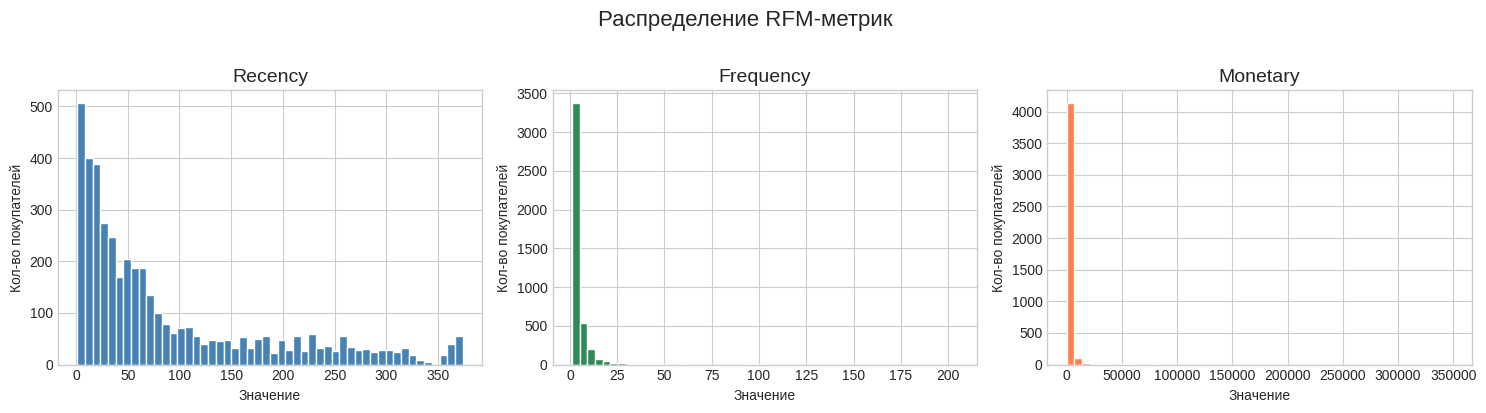

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['steelblue', 'seagreen', 'coral']):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white')
    ax.set_title(col, fontsize=14)
    ax.set_xlabel('Значение')
    ax.set_ylabel('Кол-во покупателей')

plt.suptitle('Распределение RFM-метрик', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Шаг 4: Нормализация признаков

**Почему это важно?**  
K-Means использует евклидово расстояние. Если Monetary в тысячах, а Frequency в единицах — алгоритм будет «видеть» только Monetary.

`StandardScaler` приводит каждый признак к среднему=0 и std=1.

**Важно:** мы также применим `log1p` к данным, потому что распределения сильно скошены (есть выбросы с очень большими тратами).

In [9]:
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# log1p(x) = log(1+x) — сжимает выбросы, безопасен для 0
features_log = np.log1p(features)

# Стандартизация: среднее=0, std=1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_log)

print('После нормализации (первые 5 строк):')
print(pd.DataFrame(features_scaled, columns=['Recency', 'Frequency', 'Monetary']).head())
print()
print('Среднее каждого признака (должно быть ≈0):', features_scaled.mean(axis=0).round(10))
print('Std каждого признака (должно быть ≈1):    ', features_scaled.std(axis=0).round(10))

После нормализации (первые 5 строк):
   Recency  Frequency  Monetary
0     0.97       1.61     -0.54
1    -1.90      -0.39      0.45
2     0.36      -0.98     -0.94
3    -0.06       0.02      1.00
4    -1.05      -0.98     -0.71

Среднее каждого признака (должно быть ≈0): [-0. -0. -0.]
Std каждого признака (должно быть ≈1):     [1. 1. 1.]


## Шаг 5: Как работает K-Means?

Алгоритм K-Means:
1. Случайно выбирает K точек — **центроиды**
2. Каждой точке присваивает ближайший центроид (по евклидову расстоянию)
3. Пересчитывает центроид как среднее точек в кластере
4. Повторяет шаги 2–3 до сходимости

**Главный вопрос: как выбрать K?**

### Метод «локтя» (Elbow Method)

Смотрим на **инерцию** — сумму квадратов расстояний от точек до своего центроида.  
При увеличении K инерция падает. Ищем «локоть» — точку, после которой падение замедляется.

In [10]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(features_scaled, labels))
    print(f'K={k}: инерция={km.inertia_:.1f}, silhouette={silhouette_score(features_scaled, labels):.3f}')

K=2: инерция=6603.9, silhouette=0.422


K=3: инерция=4971.0, silhouette=0.328


K=4: инерция=3976.7, silhouette=0.332


K=5: инерция=3346.8, silhouette=0.319


K=6: инерция=2925.1, silhouette=0.312


K=7: инерция=2611.1, silhouette=0.307


K=8: инерция=2397.7, silhouette=0.281


K=9: инерция=2212.6, silhouette=0.276


K=10: инерция=2050.6, silhouette=0.281


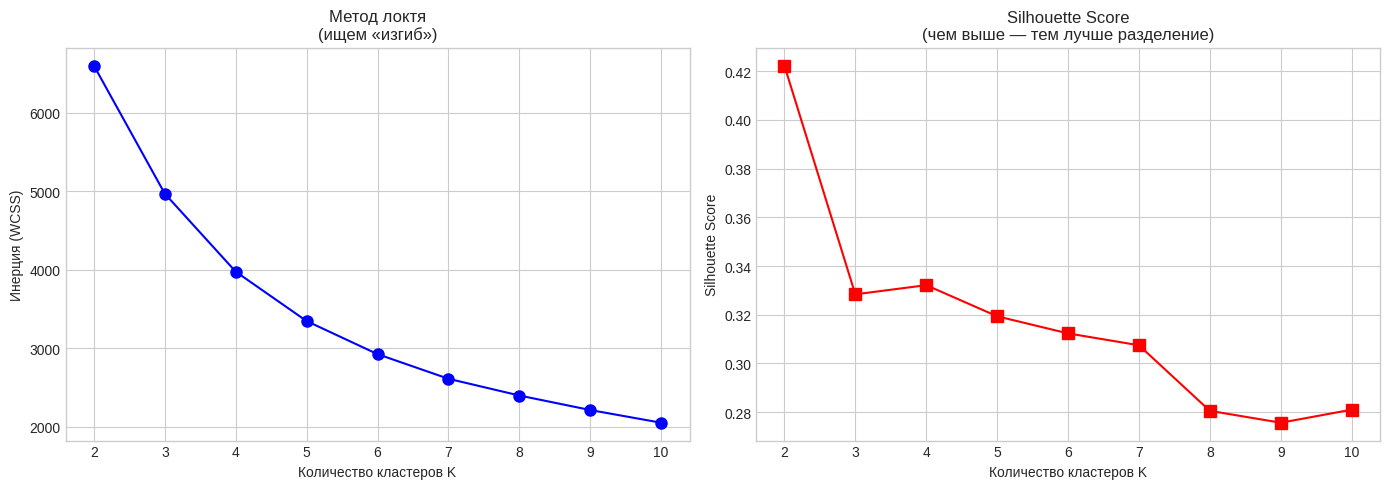


Лучший K по Silhouette: 2


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Метод локтя
ax1.plot(list(K_range), inertias, 'bo-', markersize=8)
ax1.set_xlabel('Количество кластеров K')
ax1.set_ylabel('Инерция (WCSS)')
ax1.set_title('Метод локтя\n(ищем «изгиб»)')
ax1.set_xticks(list(K_range))

# Silhouette score
ax2.plot(list(K_range), silhouettes, 'rs-', markersize=8)
ax2.set_xlabel('Количество кластеров K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score\n(чем выше — тем лучше разделение)')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'\nЛучший K по Silhouette: {best_k}')

## Шаг 6: Обучение финальной модели

Выбираем K на основе метода локтя и silhouette score. Обычно выбирают K=3 или K=4 для RFM — это удобно интерпретировать.

In [12]:
K = 4  # можно поменять на другое значение

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(features_scaled)

print(f'Распределение покупателей по {K} кластерам:')
print(rfm['Cluster'].value_counts().sort_index())

Распределение покупателей по 4 кластерам:
Cluster
0     949
1     776
2    1397
3    1190
Name: count, dtype: int64


## Шаг 7: Анализ и интерпретация кластеров

Сам по себе номер кластера ничего не значит. Нужно понять: **кто живёт в каждом кластере?**

In [13]:
cluster_summary = rfm.groupby('Cluster').agg(
    Покупателей  = ('Customer ID', 'count'),
    Recency_avg  = ('Recency',    'mean'),
    Frequency_avg= ('Frequency',  'mean'),
    Monetary_avg = ('Monetary',   'mean'),
).round(1)

print('Средние значения RFM по кластерам:')
cluster_summary

Средние значения RFM по кластерам:


,Покупателей,Recency_avg,Frequency_avg,Monetary_avg
Cluster,,,,
0,949,23.10,2.10,565.80
1,776,13.90,13.60,7422.70
2,1397,187.60,1.30,302.50
3,1190,82.70,4.10,1775.20


/tmp/ipykernel_208964/3457978481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=col, palette=palette, ax=ax)
/tmp/ipykernel_208964/3457978481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=col, palette=palette, ax=ax)
/tmp/ipykernel_208964/3457978481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=col, palette=palette, ax=ax)


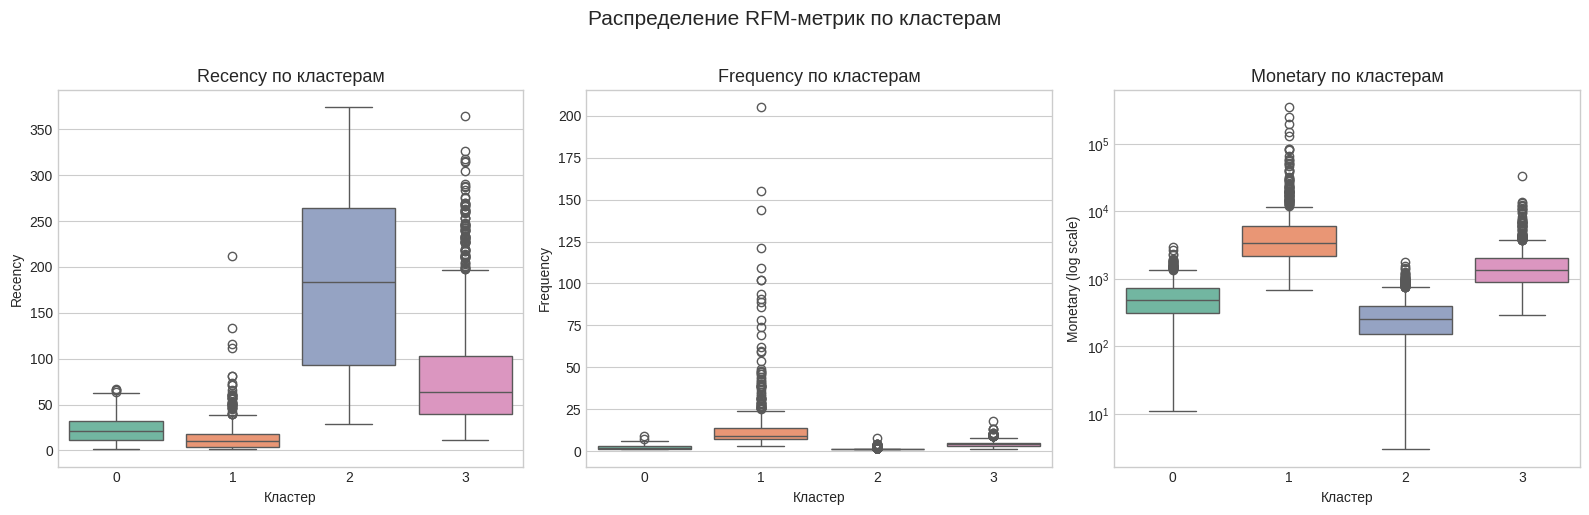

In [14]:
# Визуализация: boxplot по каждому признаку
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette('Set2', K)

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(data=rfm, x='Cluster', y=col, palette=palette, ax=ax)
    ax.set_title(f'{col} по кластерам', fontsize=13)
    ax.set_xlabel('Кластер')
    if col == 'Monetary':
        ax.set_yscale('log')
        ax.set_ylabel(f'{col} (log scale)')

plt.suptitle('Распределение RFM-метрик по кластерам', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

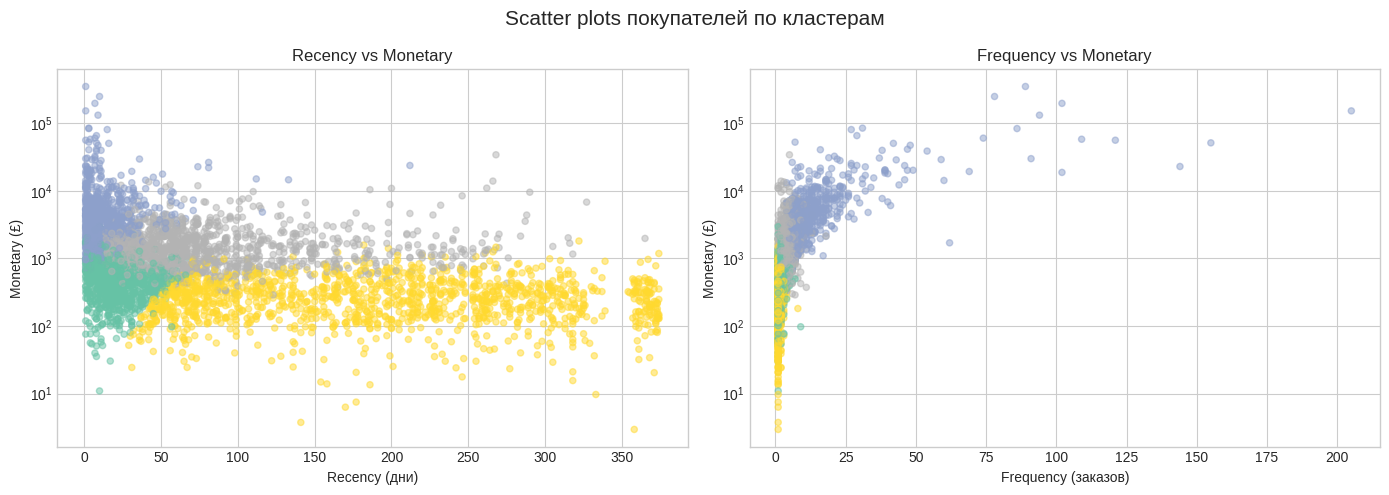

In [15]:
# Scatter plot: Recency vs Monetary, цвет = кластер
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    rfm['Recency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='Set2', alpha=0.5, s=20
)
axes[0].set_xlabel('Recency (дни)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_yscale('log')
axes[0].set_title('Recency vs Monetary')

axes[1].scatter(
    rfm['Frequency'], rfm['Monetary'],
    c=rfm['Cluster'], cmap='Set2', alpha=0.5, s=20
)
axes[1].set_xlabel('Frequency (заказов)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_yscale('log')
axes[1].set_title('Frequency vs Monetary')

plt.suptitle('Scatter plots покупателей по кластерам', fontsize=15)
plt.tight_layout()
plt.show()

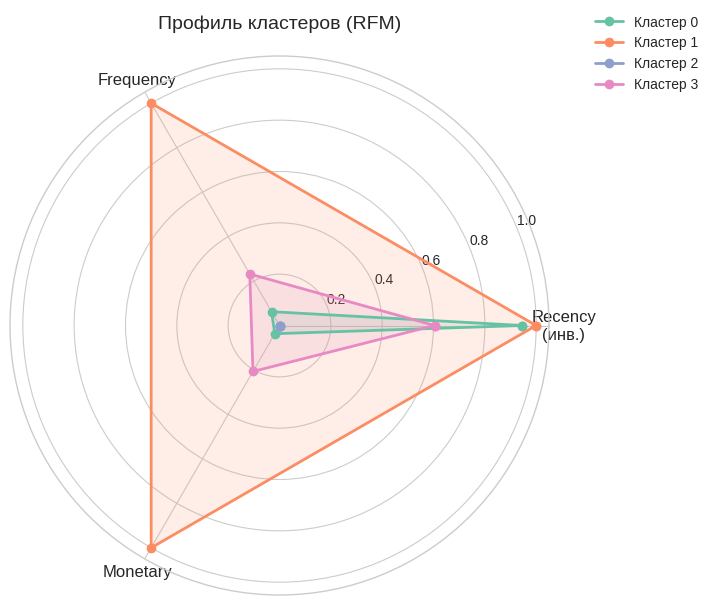

In [16]:
# Radar chart — «портрет» каждого кластера
from matplotlib.patches import FancyArrowPatch

# Нормализуем средние к диапазону [0,1] для радара
radar_df = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Recency — меньше = лучше, инвертируем
radar_df['Recency'] = radar_df['Recency'].max() - radar_df['Recency']

# Нормализация к [0,1]
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

labels = ['Recency\n(инв.)', 'Frequency', 'Monetary']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', K)

for i, (cluster, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Кластер {cluster}', color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)
ax.set_title('Профиль кластеров (RFM)', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## Шаг 8: Именование кластеров

Финальный шаг — дать кластерам **бизнес-названия** на основе их RFM-профиля.

Типичные сегменты:
- **VIP / Champions** — покупали недавно, часто, много потратили
- **Лояльные** — часто покупают, но тратят меньше
- **Уходящие** — давно не покупали, но раньше были активны
- **Случайные** — редкие покупатели, мало потратили

In [17]:
print('Профили кластеров для именования:')
print(cluster_summary.to_string())
print()
print('Подсказка:')
print('  Recency_avg  — меньше = покупал недавно (лучше)')
print('  Frequency_avg — больше = покупал чаще (лучше)')
print('  Monetary_avg  — больше = потратил больше (лучше)')

Профили кластеров для именования:
         Покупателей  Recency_avg  Frequency_avg  Monetary_avg
Cluster                                                       
0                949        23.10           2.10        565.80
1                776        13.90          13.60       7422.70
2               1397       187.60           1.30        302.50
3               1190        82.70           4.10       1775.20

Подсказка:
  Recency_avg  — меньше = покупал недавно (лучше)
  Frequency_avg — больше = покупал чаще (лучше)
  Monetary_avg  — больше = потратил больше (лучше)


In [18]:
# Заполните словарь после анализа cluster_summary выше
# Пример (замените под ваши результаты):
cluster_names = {
    0: 'Сегмент A',
    1: 'Сегмент B',
    2: 'Сегмент C',
    3: 'Сегмент D',
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

print('Итоговое распределение по сегментам:')
print(rfm['Segment'].value_counts())
rfm.head()

Итоговое распределение по сегментам:
Segment
Сегмент C    1397
Сегмент D    1190
Сегмент A     949
Сегмент B     776
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.00,165,11,372.86,3,Сегмент D
1,12347.00,3,2,1323.32,0,Сегмент A
2,12348.00,74,1,222.16,2,Сегмент C
3,12349.00,43,3,2671.14,3,Сегмент D
4,12351.00,11,1,300.93,0,Сегмент A


## Итог

Что мы сделали:
1. **EDA** — изучили данные, нашли пропуски
2. **Очистка** — убрали отмены, строки без покупателя
3. **Feature Engineering** — из транзакций сделали RFM-метрики
4. **Нормализация** — `log1p` + `StandardScaler`
5. **Выбор K** — метод локтя + Silhouette Score
6. **K-Means** — обучили модель
7. **Интерпретация** — поняли, кто живёт в каждом кластере

### Что попробовать дальше
- **DBSCAN** — кластеризация без указания числа кластеров, находит выбросы
- **Иерархическая кластеризация** — дендрограмма, не нужно задавать K
- **PCA + K-Means** — сначала снизить размерность, потом кластеризовать (полезно при большом числе признаков)